# Task 1: activation function in fully connected layers

This notebook focuses on the assigned hyperparameter. I compare the activation function used in the hidden fully connected layers.


In [1]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random
import time

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomContrast

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# helper function for train/test split
from sklearn.model_selection import train_test_split


## settings for this experiment

Only the activation function in the fully connected layers is changed. The dataset, split and model structure stay the same.


In [2]:
# path to the HaGRID subset. the dataset itself should not be committed
DATASET_DIR = '../misc/gesture_dataset_sample'
if not os.path.exists(DATASET_DIR):
    DATASET_DIR = 'misc/gesture_dataset_sample'

# include only those gestures
CONDITIONS = ['like', 'stop']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
COLOR_CHANNELS = 3

# variables for hyperparameters that stay fixed
batch_size = 8
epochs = 50
seed = 42
activation_conv = 'leaky_relu'  # fixed, because this is not my hyperparameter
layer_count = 2
num_neurons = 64

# assigned hyperparameter: activation function in the fully connected layers
activation_functions = ['relu', 'elu', 'selu', 'tanh', 'sigmoid']

print('Dataset:', os.path.normpath(DATASET_DIR))


Dataset: ../misc/gesture_dataset_sample


## helper function to load and parse annotations


In [3]:
annotations = dict()

for condition in CONDITIONS:
    annotation_file = os.path.join(DATASET_DIR, '_annotations', f'{condition}.json')
    with open(annotation_file) as f:
        annotations[condition] = json.load(f)

# print first element, just to check if loading worked
first_key = next(iter(annotations[CONDITIONS[0]]))
print('First example label:', annotations[CONDITIONS[0]][first_key]['labels'][0])
print('First example bbox:', annotations[CONDITIONS[0]][first_key]['bboxes'][0])


First example label: like
First example bbox: [0.38056273, 0.35650891, 0.17322347, 0.10461114]


## helper function to pre-process images (color channel conversion and resizing)


In [4]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized


## load images and annotations


In [5]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    image_dir = os.path.join(DATASET_DIR, condition)

    for filename in sorted(os.listdir(image_dir)):
        if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(os.path.join(image_dir, filename))
        if img is None:
            continue

        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except KeyError:
            continue

        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h

            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label == 'no_gesture':
                continue
            if label not in label_names:
                label_names.append(label)

            label_index = label_names.index(label)

            images.append(preprocess_image(crop))
            labels.append(label_index)

print('Loaded images:', len(images))
print('Labels:', label_names)


Loaded images: 500
Labels: ['like', 'stop']


## let's have a look at one of the images


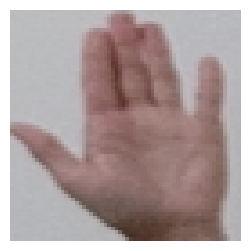

In [6]:
sample_img = random.Random(seed).choice(images)

plt.figure(figsize=(3, 3))
plt.imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


## split data set into train and test

x is for the actual data, y is for the label (this is convention)

## transform data sets into a format compatible with our neural network

image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]

furthermore, scale all values to a range of 0 to 1

training data has to be converted to a categorial vector ("one hot"):

[3] --> [0, 0, 0, 1, 0, ..., 0]


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=seed,
    stratify=labels,
)

X_train = np.array(X_train).astype('float32')
X_train = X_train / 255.

X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.

num_classes = len(label_names)
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

train_label = y_train_one_hot
test_label = y_test_one_hot

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape)
print(train_label.shape, test_label.shape)


(400, 64, 64, 3) (100, 64, 64, 3)
(400, 2) (100, 2)


## approach before training

The assigned hyperparameter is the activation function in the fully connected layers. I test five values: `relu`, `elu`, `selu`, `tanh` and `sigmoid`.

My assumption is that `relu`, `elu` and `selu` will probably work better, because they do not get flat as quickly. `tanh` and `sigmoid` can also work, but training can be slower. To compare the activations fairly, I keep the other hyperparameters the same for all runs.

For every activation function I train a new model and record the test accuracy, test loss and prediction time.


## helper function to create the model


In [8]:
def reset_seeds():
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def build_model(activation):
    # define model structure
    # with keras, we can use a model's add() function to add layers to the network one by one
    model = Sequential()
    model.add(Input(shape=(IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)))

    # data augmentation (this can also be done beforehand - but don't augment the test dataset!)
    model.add(RandomFlip('horizontal'))
    model.add(RandomContrast(0.1))

    # first, we add some convolution layers followed by max pooling
    model.add(Conv2D(64, kernel_size=(9, 9), activation=activation_conv, padding='same'))
    model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

    model.add(Conv2D(32, (5, 5), activation=activation_conv, padding='same'))
    model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

    model.add(Conv2D(32, (3, 3), activation=activation_conv, padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

    # dropout layers can drop part of the data during each epoch - this prevents overfitting
    model.add(Dropout(0.2))

    # after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
    model.add(Flatten())

    # add some fully connected layers ("Dense")
    # this is where the activation function is changed
    for i in range(layer_count):
        model.add(Dense(num_neurons, activation=activation))

    # for classification, the last layer has to use the softmax activation function
    model.add(Dense(num_classes, activation='softmax'))

    # specify loss function, optimizer and evaluation metrics
    model.compile(loss=categorical_crossentropy, optimizer='adam', metrics=['accuracy'])
    return model

# let's have a look at one model
example_model = build_model(activation_functions[0])
example_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 64, 64, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,882 (386.26 KB)

 Trainable params: 98,882 (386.26 KB)

 Non-trainable params: 0 (0.00 B)

## now, we train one model for each activation function
## this will take a while


In [9]:
results = []
histories = {}

for activation in activation_functions:
    print('Training with Dense activation:', activation)
    reset_seeds()
    model = build_model(activation)

    # define callback functions that react to the model's behavior during training
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
    stop_early = EarlyStopping(monitor='val_loss', patience=3)

    history = model.fit(
        X_train,
        train_label,
        batch_size=batch_size,
        epochs=epochs,
        verbose=0,
        validation_data=(X_test, test_label),
        callbacks=[reduce_lr, stop_early],
    )

    test_loss, test_accuracy = model.evaluate(X_test, test_label, verbose=0)

    start = time.perf_counter()
    model.predict(X_test, verbose=0)
    prediction_time = time.perf_counter() - start

    results.append({
        'activation': activation,
        'test_accuracy': test_accuracy,
        'test_loss': test_loss,
        'prediction_time_ms_per_image': prediction_time / len(X_test) * 1000,
        'epochs_trained': len(history.history['loss']),
    })
    histories[activation] = history.history

print()
print(f"{'activation':>10} | {'test acc':>8} | {'loss':>8} | {'ms/img':>8} | {'epochs':>6}")
print('-' * 58)
for row in results:
    print(
        f"{row['activation']:>10} | "
        f"{row['test_accuracy']:8.4f} | "
        f"{row['test_loss']:8.4f} | "
        f"{row['prediction_time_ms_per_image']:8.3f} | "
        f"{row['epochs_trained']:6d}"
    )


Training with Dense activation: relu


Training with Dense activation: elu


Training with Dense activation: selu


Training with Dense activation: tanh


Training with Dense activation: sigmoid



activation | test acc |     loss |   ms/img | epochs
----------------------------------------------------------
      relu |   0.9900 |   0.0955 |    4.404 |     22
       elu |   0.9600 |   0.1284 |    8.674 |     15
      selu |   0.9700 |   0.1033 |    3.376 |     16
      tanh |   0.9100 |   0.1930 |    3.625 |     16
   sigmoid |   0.9700 |   0.1269 |    2.882 |     22


## plot accuracy and prediction time


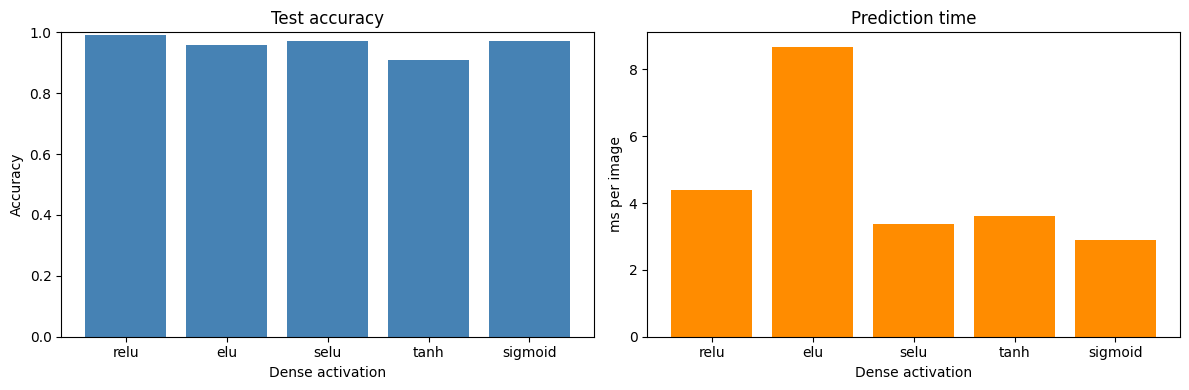

In [10]:
activations = [row['activation'] for row in results]
accuracies = [row['test_accuracy'] for row in results]
prediction_times = [row['prediction_time_ms_per_image'] for row in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(activations, accuracies, color='steelblue')
axes[0].set_title('Test accuracy')
axes[0].set_xlabel('Dense activation')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)

axes[1].bar(activations, prediction_times, color='darkorange')
axes[1].set_title('Prediction time')
axes[1].set_xlabel('Dense activation')
axes[1].set_ylabel('ms per image')

plt.tight_layout()
plt.show()


## plot validation accuracy of the training process


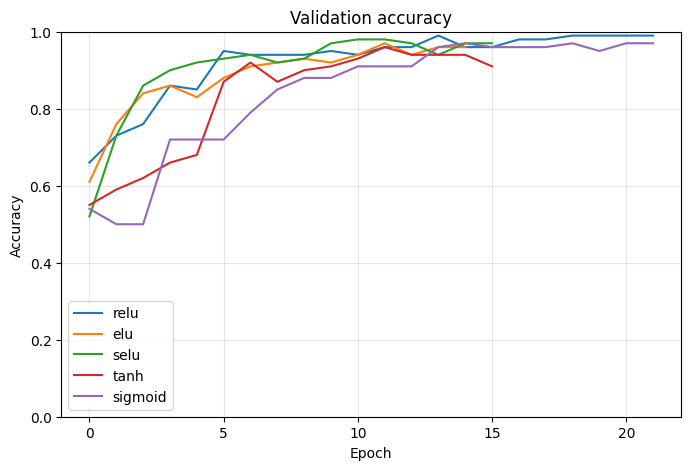

In [11]:
plt.figure(figsize=(8, 5))

for activation, history in histories.items():
    plt.plot(history['val_accuracy'], label=activation)

plt.title('Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## short result


In [12]:
best_accuracy = max(results, key=lambda row: row['test_accuracy'])
fastest = min(results, key=lambda row: row['prediction_time_ms_per_image'])

print('Best accuracy:', best_accuracy['activation'], f"({best_accuracy['test_accuracy']:.4f})")
print('Fastest prediction:', fastest['activation'], f"({fastest['prediction_time_ms_per_image']:.3f} ms/image)")


Best accuracy: relu (0.9900)
Fastest prediction: sigmoid (2.882 ms/image)


## discussion

In this run `relu` worked best for accuracy. It got the highest test accuracy with 0.99. `selu` and `sigmoid` were close with 0.97, `elu` got 0.96 and `tanh` was lower with 0.91. The measured prediction times were all in the same small range, so I do not use them as the main reason for choosing an activation function.

This mostly fits my assumption. The ReLU-like functions worked well for this CNN. `tanh` and `sigmoid` also can work, but their function can become flat, so the training can be harder. The prediction time should not be over-interpreted, because the test set is small and most calculation is done in the convolution layers.

I would use `relu` for this model, because it had the best accuracy in this experiment and it is also a common standard choice.
